In [57]:
!pwd

/home/isaiah/Documents/Spring25/SP/Cognitive-Canvas-EEG/notebooks/dtcwt


In [58]:
import pandas as pd

from pathlib import Path


import typer
from loguru import logger
from tqdm import tqdm
import os
import antropy as ant
import sklearn
from sklearn.decomposition import PCA
import numpy as np 
import mne
from itertools import combinations

app = typer.Typer()

# TODO: make variable names consistent 

FEATURE_NAMES = ["hjorth_activity", "hjorth_mobility", "hjorth_complexity", "katz_FD" ]
EEG_COLUMNS = ['EEG.FC5','EEG.FC6']

SFREQ = 128

class FeatureAbstraction():
    def __init__(self,n,input_path: Path, output_path: Path):
        self.principal=PCA(n_components=n)
        self.input_path = input_path
        self.output_path = output_path
        self.bands = {
            'Delta': (0.5, 4),
            'Theta': (4, 8),
            'Alpha': (8, 13),
            'Beta': (13, 30)
        }

    def get_eeg_df(self, csv_path):
        subject_df = pd.read_csv(csv_path)
        return subject_df[EEG_COLUMNS], subject_df['Label']

    def hjorth_params(self,df_eeg):
        activity = np.var(df_eeg.to_numpy().T,axis=-1)
        mobility, complexity = ant.hjorth_params(df_eeg.to_numpy().T)

        return activity,mobility,complexity

    def katz_fractals(self,df_eeg):
        return ant.katz_fd(df_eeg.to_numpy().T)

    def pca(self,x):
        self.principal.fit(x)
        return self.principal.transform(x)
    
    def get_ratios(self, band1, band2):
        return band1 / band2

    def get_mne_raw(self, denoised_eeg, fourchan=False):
        if fourchan:
            EEG_COLUMNS = ['EEG.F3','EEG.FC5','EEG.FC6','EEG.F4']
        if denoised_eeg.shape[1] == 2:
            info = mne.create_info(ch_names=['EEG.FC5', 'EEG.FC6'], sfreq=SFREQ, ch_types='eeg')
        else:
            info = mne.create_info(ch_names=EEG_COLUMNS, sfreq=SFREQ, ch_types='eeg')
        raw = mne.io.RawArray(denoised_eeg.transpose(), info)
        return raw
    
    def bandpower(self, psd, freqs, band):
        band_freqs = np.logical_and(freqs >= band[0], freqs <= band[1])
        band_power = np.mean(psd[:, :, band_freqs], axis=-1) # averaging across all epochs 
        # psd --> [number of epochs, n_channels, n_time_points]
        # breakpoint()
        return np.mean(band_power, axis=0) # averages across all epochs 
    
    def get_mew(self, denoised_eeg_df):
        raw = self.get_mne_raw(denoised_eeg_df[['EEG.FC5', 'EEG.FC6']])
        p = raw.compute_psd()
        freqs = p.freqs 
        psd_data = p.data 

        mew_power = self.bandpower(np.expand_dims(psd_data, axis=0), freqs, (8,12))
        mean_power = np.mean(mew_power)
        return {'Mu' : np.mean(mean_power)}
    
    
    def spectral_power(self, denoised_eeg_df, fourchan=False):

        if fourchan:
            denoised_eeg_df = denoised_eeg_df[['EEG.F3','EEG.FC5','EEG.FC6','EEG.F4']]

        raw = self.get_mne_raw(denoised_eeg_df, fourchan=fourchan)
        p = raw.compute_psd()
        freqs = p.freqs 
        psd_data = p.data 

        band_powers = {band: self.bandpower(np.expand_dims(psd_data, axis=0), freqs, self.bands[band]) for band in self.bands}
        bands_names = list(band_powers.keys())

        # breakpoint()

        mean_powers = [np.mean(band_powers[band]) for band in bands_names]

        return {band: np.mean(band_powers[band]) for band in bands_names}
    
    def batches(self, fourchan=False):
        feature_df = pd.DataFrame(columns=['hjorth_activity', 'hjorth_mobility', 'hjorth_complexity','katz_FD', 'Label'])
        big_out = []
        for csv in tqdm(os.listdir(self.input_path)):
            if csv.endswith(".csv") and csv.startswith("raw"):
                csv_path = os.path.join(self.input_path, csv)

                eeg_df, label = self.get_eeg_df(csv_path)
                components = self.pca(eeg_df)

                bands = self.spectral_power(eeg_df, fourchan=fourchan)
                mew = self.get_mew(eeg_df)

                band_ratio = self.get_ratios(bands['Beta'], mew['Mu'])

                activity, mobility, complexity = self.hjorth_params(eeg_df)
                fractals = self.katz_fractals(eeg_df)

                data = ([activity, mobility, complexity, fractals])

                out = []
                for i, d in enumerate(data):
                    list_name = [FEATURE_NAMES[i] + "_" + s for s in EEG_COLUMNS]
                    out.append(dict(zip(list_name, d)))

                big_out.append(out[0] | out[1] | out[2] | out[3] | {'BMu Ratio' : band_ratio} | bands | mew | {'Label': label[0]})

                # breakpoint()

                # temp_df = pd.DataFrame({'hjorth_activity': activity, 'hjorth_mobility': mobility, 
                #                         'hjorth_complexity' : complexity,'katz_FD' : fractals,
                #                         'Label' : label[:14]})
                # feature_df = pd.concat([feature_df, temp_df], ignore_index=True)

                # breakpoint()
        
        feature_df = pd.DataFrame(big_out)

        feature_df.to_csv(f"{self.output_path}/feature_df.csv", index=False)


In [59]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd 
import dtcwt
import mne 
from scipy.stats import entropy
from tqdm import tqdm
import os 


LEVELS = 5
transform = dtcwt.Transform1d()

def shannon_entropy(signal):
    value, counts = np.unique(signal, return_counts=True)
    probs = counts / len(signal)

    # Calculate the Shannon entropy using scipy.stats.entropy
    return entropy(probs)

def dual_wavelet_features(X):
    coeffs = transform.forward(X, nlevels=LEVELS)

    real = []
    imag = []


    real.append(coeffs.lowpass.real)
    imag.append(coeffs.lowpass.imag)

    for i in range(LEVELS):
        real.append(coeffs.highpasses[i].real)
        imag.append(coeffs.highpasses[i].imag)

    vars = []
    shannon_entropies = []

    for i in range(LEVELS):
        vars.append(np.var(real[i]))
        vars.append(np.var(imag[i]))

        shannon_entropies.append(shannon_entropy(real[i]))
        shannon_entropies.append(shannon_entropy(imag[i])) # double check if this is being done correctly 


    features = np.array(vars) * np.array(shannon_entropies)

    return features

def pipeline(input_path,output_path,channels):
    f = FeatureAbstraction(n=3, input_path=input_path, output_path=output_path)

    all_left_features = []
    all_right_features = []
    all_features = []

    for csv in tqdm(os.listdir(input_path)):
        
        if csv.endswith(".csv") and csv.startswith("raw") and (("RIGHT" in csv) or ("LEFT" in csv)):
            eeg_df, label = f.get_eeg_df(os.path.join(input_path,csv))
            channel_features = []
            for channel in channels:
                
                eeg_signal_df = eeg_df[channel]
                eeg_signal = eeg_signal_df.to_numpy()

                mne.filter.filter_data(eeg_signal,sfreq=128,l_freq=0.5,h_freq=30)
                features = dual_wavelet_features(eeg_signal) 

                if "LEFT" in csv:
                    all_left_features.append(features)
                    
                if "RIGHT" in csv:
                    all_right_features.append(features)

        
                channel_features.append((features))

            if "LEFT" in csv:
                all_features.append(np.append(np.concatenate(channel_features),[0]))

            if "RIGHT" in csv:
                all_features.append(np.append(np.concatenate(channel_features),[1]))


    return all_left_features, all_right_features, all_features

In [60]:

input_path = '../../data/interim'
output_path = '../../data/processed'
left1, right1, all1 = pipeline(input_path,output_path,channels=EEG_COLUMNS)





left_features = np.array(left1)
right_features = np.array(right1)

  0%|          | 0/118 [00:00<?, ?it/s]

Setting up band-pass filter from 0.5 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 845 samples (6.602 s)

Setting up band-pass filter from 0.5 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- 

/tmp/ipykernel_464411/2217580830.py:67: RuntimeWarning: filter_length (845) is longer than the signal (724), distortion is likely. Reduce filter length or filter a longer signal.
  mne.filter.filter_data(eeg_signal,sfreq=128,l_freq=0.5,h_freq=30)
/tmp/ipykernel_464411/2217580830.py:67: RuntimeWarning: filter_length (845) is longer than the signal (724), distortion is likely. Reduce filter length or filter a longer signal.
  mne.filter.filter_data(eeg_signal,sfreq=128,l_freq=0.5,h_freq=30)
/tmp/ipykernel_464411/2217580830.py:67: RuntimeWarning: filter_length (845) is longer than the signal (710), distortion is likely. Reduce filter length or filter a longer signal.
  mne.filter.filter_data(eeg_signal,sfreq=128,l_freq=0.5,h_freq=30)
/tmp/ipykernel_464411/2217580830.py:67: RuntimeWarning: filter_length (845) is longer than the signal (710), distortion is likely. Reduce filter length or filter a longer signal.
  mne.filter.filter_data(eeg_signal,sfreq=128,l_freq=0.5,h_freq=30)
  5%|▌      

Setting up band-pass filter from 0.5 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 845 samples (6.602 s)

Setting up band-pass filter from 0.5 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)


/tmp/ipykernel_464411/2217580830.py:67: RuntimeWarning: filter_length (845) is longer than the signal (720), distortion is likely. Reduce filter length or filter a longer signal.
  mne.filter.filter_data(eeg_signal,sfreq=128,l_freq=0.5,h_freq=30)


...

/tmp/ipykernel_464411/2217580830.py:67: RuntimeWarning: filter_length (845) is longer than the signal (702), distortion is likely. Reduce filter length or filter a longer signal.
  mne.filter.filter_data(eeg_signal,sfreq=128,l_freq=0.5,h_freq=30)


Setting up band-pass filter from 0.5 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 845 samples (6.602 s)



/tmp/ipykernel_464411/2217580830.py:67: RuntimeWarning: filter_length (845) is longer than the signal (762), distortion is likely. Reduce filter length or filter a longer signal.
  mne.filter.filter_data(eeg_signal,sfreq=128,l_freq=0.5,h_freq=30)


Setting up band-pass filter from 0.5 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 845 samples (6.602 s)



/tmp/ipykernel_464411/2217580830.py:67: RuntimeWarning: filter_length (845) is longer than the signal (762), distortion is likely. Reduce filter length or filter a longer signal.
  mne.filter.filter_data(eeg_signal,sfreq=128,l_freq=0.5,h_freq=30)
100%|██████████| 118/118 [00:03<00:00, 30.22it/s]


In [61]:
from sklearn.model_selection import train_test_split


all = np.array(all1)

print(all)

df = pd.DataFrame(np.array(all))

X = df.iloc[:, :-1]
y = df.iloc[:,-1]

# # df.rename(columns={'0':'RB1', '1': 'IB1','2': 'RB2', '3': 'IB2','4': 'RB3', '5': 'IB3','6': 'RB4', '7': 'IB4'}, inplace=True)

[[9.56458238e+03 0.00000000e+00 1.01567673e+01 4.48130600e+00
  6.19361662e+01 3.42783164e+01 3.04478918e+02 2.37428150e+02
  3.45431838e+02 3.07043230e+02 1.00483076e+04 0.00000000e+00
  1.43783342e+01 7.76033912e+00 8.51281353e+01 7.86885888e+01
  5.92608762e+02 6.24279689e+02 4.58791197e+02 5.85650360e+02
  1.00000000e+00]
 [2.36151869e+04 0.00000000e+00 2.50991365e+02 2.08991050e+02
  4.19017337e+02 3.39385265e+02 4.14044158e+02 3.73905813e+02
  5.09778429e+02 4.14803624e+02 2.69526998e+04 0.00000000e+00
  1.68973790e+01 1.25050499e+01 8.76423569e+01 6.08665547e+01
  5.63454001e+02 5.78716635e+02 6.62033586e+02 5.53961476e+02
  0.00000000e+00]
 [1.01025344e+04 0.00000000e+00 2.14603797e+01 9.61600464e+00
  9.83597104e+01 8.52641494e+01 2.41220136e+02 3.00904008e+02
  4.08292712e+02 3.83788737e+02 4.05610186e+03 0.00000000e+00
  2.58029633e+01 1.35283411e+01 1.52665607e+02 1.09121212e+02
  6.18419131e+02 7.86221116e+02 7.41682557e+02 6.89829853e+02
  1.00000000e+00]
 [1.39962634e+04

In [62]:

def compute_within_class_scatter(features, labels):
    unique_labels = np.unique(labels)
    num_features = features.shape[1]
    Sw = np.zeros((num_features, num_features))

    for label in unique_labels:
        class_features = features[labels == label]
        class_mean = np.mean(class_features, axis=0)
        class_cov = np.cov(class_features, rowvar=False)
        Sw += class_cov

    return Sw

def compute_mixture_scatter(features):
    num_features = features.shape[1]
    overall_mean = np.mean(features, axis=0)
    Sm = np.cov(features, rowvar=False)
    return Sm

def compute_j3(Sw, Sm):
    # Compute the inverse of Sw
    Sw_inv = np.linalg.pinv(Sw)
    
    # Compute J3
    J3 = np.trace(np.dot(Sw_inv, Sm))
    return J3

def select_optimal_features(features, labels, num_features_to_select):
    num_features = features.shape[1]
    best_J3 = -np.inf
    best_features = None

    # Generate all possible combinations of features with the specified size
    for feature_indices in combinations(range(num_features), num_features_to_select):
        selected_features = features[:, feature_indices]
        Sw = compute_within_class_scatter(selected_features, labels)
        Sm = compute_mixture_scatter(selected_features)
        current_J3 = compute_j3(Sw, Sm)

        if current_J3 > best_J3:
            best_J3 = current_J3
            best_features = feature_indices

    return best_features

num_features_to_select = 4  # Number of features to select
best_feature_indices = select_optimal_features(X.to_numpy(), y.to_numpy(), num_features_to_select)

print(f"Best feature indices: {best_feature_indices}")

features = X.to_numpy()
selected_features = features[:, best_feature_indices]

X_best = pd.DataFrame(selected_features)


Best feature indices: (6, 7, 8, 9)


In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(X_best, y, test_size=0.4000, random_state=16)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.3333, random_state=16)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

neigh = KNeighborsClassifier(n_neighbors=6,p=2)
neigh.fit(X_train, y_train)

preds = (neigh.predict(X_val))

acc = accuracy_score(y_val,preds)
print(acc)

print(y_val)
print(preds)

## NEED TO PKL THIS MODEL LOL 
# indicies ((6, 7, 8, 9))

0.8333333333333334
26    1.0
37    1.0
34    0.0
17    0.0
6     1.0
29    1.0
11    0.0
3     0.0
28    1.0
39    1.0
23    1.0
27    0.0
Name: 20, dtype: float64
[1. 0. 0. 0. 0. 1. 0. 0. 1. 1. 1. 0.]


In [ ]:
preds = (neigh.predict(X_test))

acc = accuracy_score(y_test,preds)
print(acc)

print(y_test)
print(preds)




1.0
22    1.0
21    1.0
24    0.0
7     0.0
33    1.0
15    0.0
Name: 20, dtype: float64
[1. 1. 0. 0. 1. 0.]


In [73]:
# save this model 

import pickle
# Assuming 'model' is your trained machine learning model
with open('knn_83_val.pkl', 'wb') as file:
    pickle.dump(neigh, file)

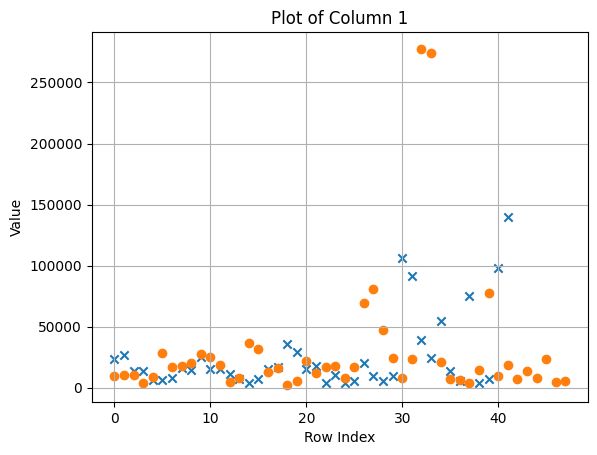

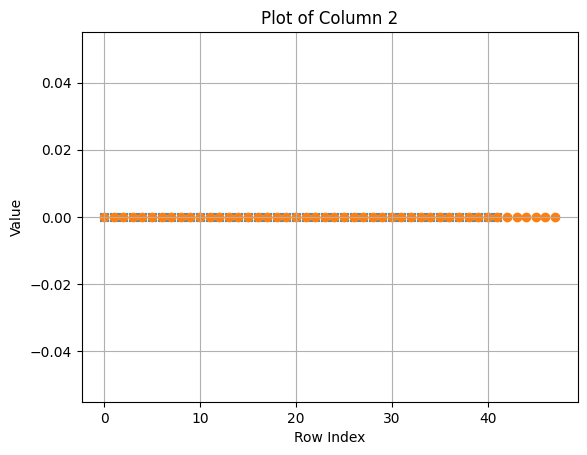

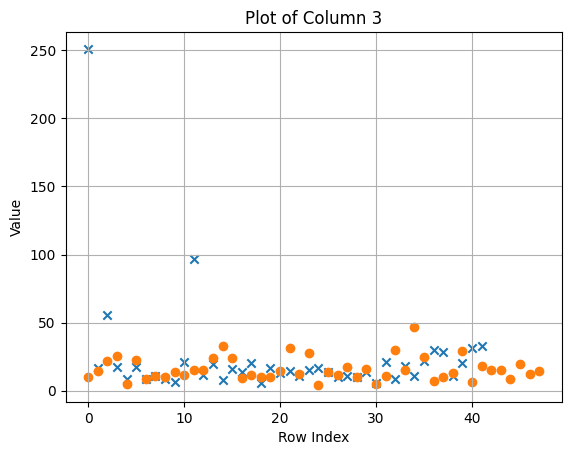

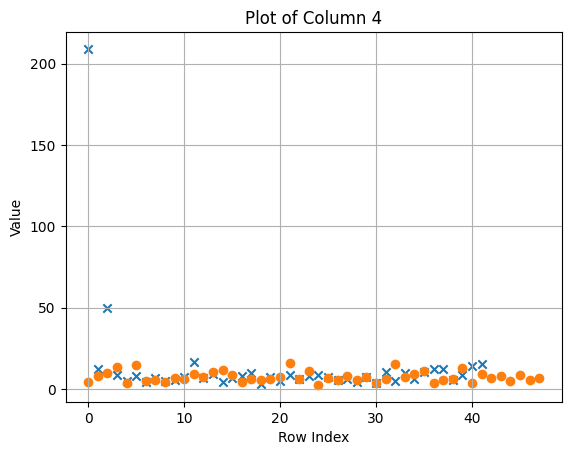

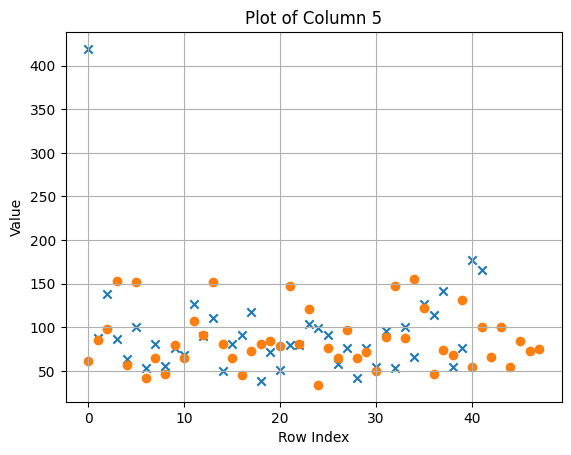

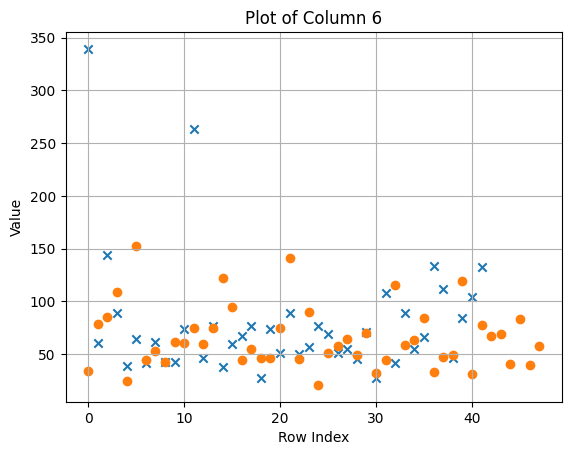

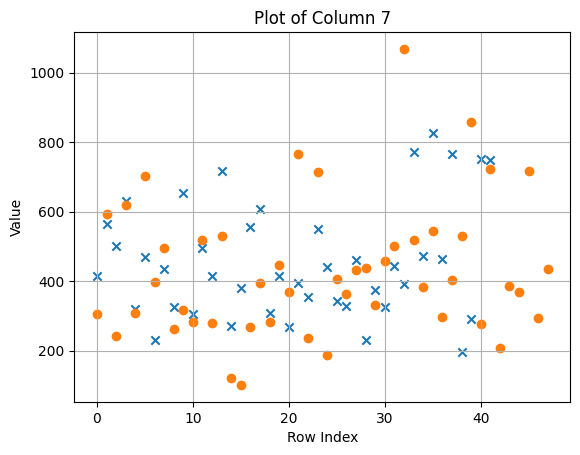

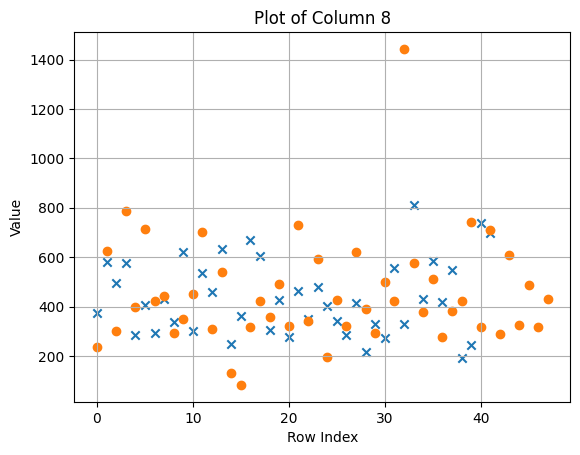

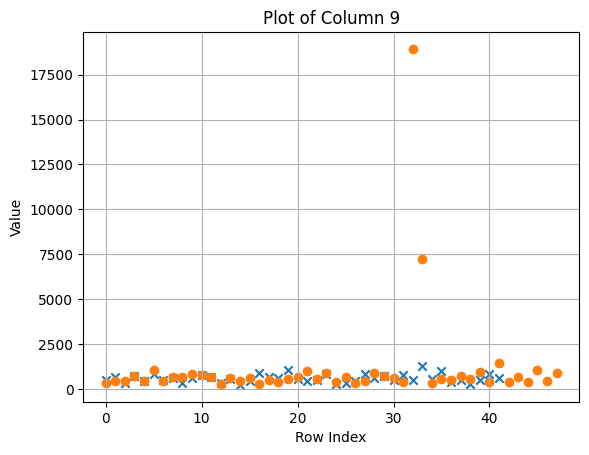

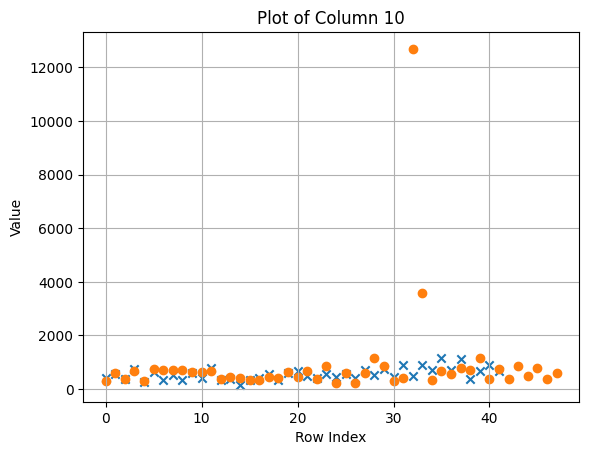

In [72]:
for i in range(left_features.shape[1]):
    plt.figure()  # Create a new figure for each column
    plt.scatter(range(left_features.shape[0]), left_features[:, i],marker='x') 
    plt.scatter(range(right_features.shape[0]), right_features[:, i],marker='o') 
    plt.title(f'Plot of Column {i + 1}')
    plt.xlabel('Row Index')
    plt.ylabel('Value')
    plt.grid(True)
    plt.show()